Questions for Feroz:<p>
 - Q14:
    - What is a Conventional Model? Anything in Part 2?
    - Histplot or boxplot? template had BoxPlot.

# OVERVIEW

In this lab, you will perform a supervised text regression task. The data for the task will consist of student essays from The William and Flora Hewlett Foundation. The dataset was created to assist in the design of solutions for automated grading of student-written essays. You will use a subset of this dataset and predict the scores of the essays. You may not use external data to make predictions. 



In [338]:
from numpy.random import seed
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from sklearn.linear_model import Ridge, Lasso
import tensorflow_hub as hub

# PART 1: SETUP

### Q0: Run the following code! 
    
For reproducibility purposes, you will set the random seeds for NumPy and TensorFlow as 1234.  This way, all random steps will produce the same answers.


In [339]:
seed(1234)
tf.random.set_seed(seed = 1234)

### Q1: Load the data
🎒<font color='red'>(1 point)</font>

We will use data from the [automated essay scoring task](https://www.kaggle.com/c/asap-aes) on Kaggle.

We will only use the training data, which we have provided for you -- you don't need to download anything from Kaggle.

Access the file `training_set_rel3.tsv` from Files -> Module 5 -> Lab_05_15_Text_Classification -> training_set_rel3.tsv

Please load the data from the current directory so that we can run your notebook unmodified.  

Use the pandas function `read_csv`, with the parameter `sep=\t` because this is a tab-separated value file (tsv) and set  the parameter `encoding='latin-1'`. 

The columns are described on the [Kaggle site](https://www.kaggle.com/competitions/asap-aes/data)

We will use three columns: `essay`, `essay_set`, and `domain1_score`.

Create a new dataframe with only these three columns, and rename `domain1_score` to just `score`.

Display this dataframe.

In [340]:
raw = pd.read_csv("Lab-5-15_training_set_rel3-1.tsv", sep='\t', encoding='latin-1')

## Q2: Select the data from a single essay set
🎒<font color='red'>(1 point)</font>

There are 8 totally unrelated essay sets in this data.

Filter the data frame so we are only considering essay_set = 7

In [341]:
raw.head(3)
alldata = raw[['essay_set', 'essay', 'domain1_score']].rename(columns={'domain1_score': 'score'})
data = alldata[alldata['essay_set'] == 7]
display(data)
print(data.shape)

,essay_set,essay,score
10684,7,Patience is when your waiting .I was patience ...,15
10685,7,"I am not a patience person, like I cant sit i...",13
10686,7,One day I was at basketball practice and I was...,15
10687,7,I going to write about a time when I went to t...,17
10688,7,It can be very hard for somebody to be patient...,13
...,...,...,...
12248,7,One time I was getting a cool @CAPS1 game it w...,12
12249,7,A patent person in my life is my mom. Aicason ...,16
12250,7,A time when someone else I know was patient wa...,19
12251,7,I hate weddings. I love when people get marrie...,22


(1569, 3)


### Q3: Plot the distribution of scores
🎒<font color='red'>(3 points)</font>

Create a plot of a histogram of the scores in the training set.  Comment on what you see.  

One option is to use the [seaborn](https://seaborn.pydata.org/) histplot function.  If you use seaborn, you can use the parameter `bins` to set the bin locations if they look strange. The parameter accepts a list of explicit locations. If you want to center the bins on the tick marks, you cand do something like this:

    bins=np.arange(minv,maxv)-0.5
    
where minv and maxv are the mininmum and maximum value in the range, respectively.   This expression indicates the number of possible scores, and that the tick marks should be at the halfway mark of each bar.

You may use some other visualization library if you wish!   The goal is to inspect the distribution of scores.


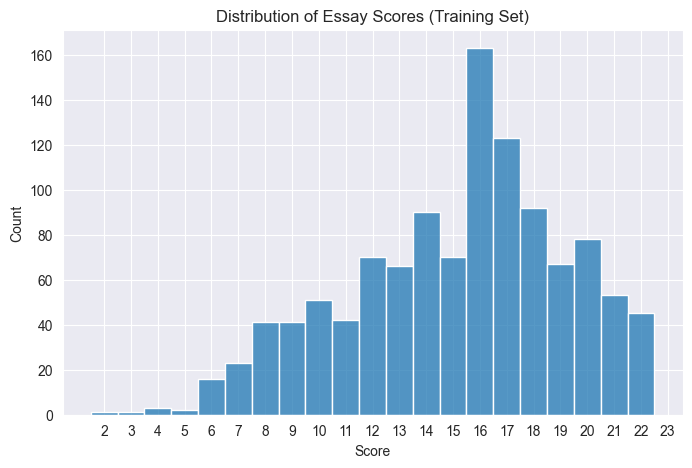

In [342]:
# Instructions say "the training set", I will do both because it doessn't make sense here with the next question.
train, test = train_test_split(data, test_size=0.2)
minv = train['score'].min()
maxv = train['score'].max()
bins = np.arange(minv, maxv) - 0.5

plt.figure(figsize=(8, 5))
sns.histplot(train['score'], bins=bins, kde=False)
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Distribution of Essay Scores (Training Set)')
plt.xticks(np.arange(minv, maxv))
plt.show()

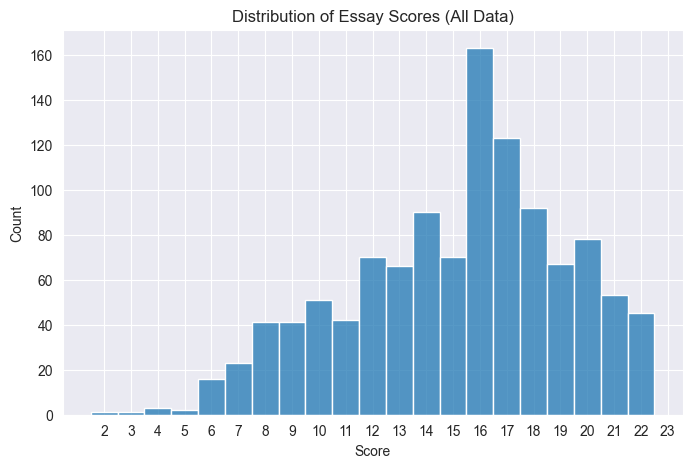

In [343]:
# All Data
minv = data['score'].min()
maxv = data['score'].max()
bins = np.arange(minv, maxv) - 0.5
plt.figure(figsize=(8, 5))
sns.histplot(train['score'], bins=bins, kde=False)
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Distribution of Essay Scores (All Data)')
plt.xticks(np.arange(minv, maxv))
plt.show()

I did both full and training data and the histograms look virtually identical.<p>
This histogram shows the distribution of essay scores in the training set. The x-axis represents the test score, while the y-axis represents the count of essays that received each score.<p>
The distribution appears to be somewhat uniform, with a peak around the middle scores but skewed a little towards the higher end. This suggests that most essays received average scores, while fewer essays received very low or very high scores. The range of scores is from 2 to 22, with each score having a similar number of essays assigned to it.

### Q4: Create a test/train split
🎒<font color='red'>(1 point)</font>

Use the function [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).  Use the `test_size` parameter to control the size of the test set; use 0.2 to indicate a 20% split.

In [344]:
train, test = train_test_split(data, test_size=0.2)
train

,essay_set,essay,score
11553,7,It was patient waiting to go to @CAPS1. It wen...,17
10765,7,One time when I was patient was when there was...,17
11493,7,When you have patience you are colmer peace fu...,8
10804,7,@CAPS1 @CAPS2 my teacher said @CAPS3 we are...,19
11068,7,A Time I was patient was the time @CAPS1 @CAPS...,16
...,...,...,...
12188,7,"Hi, Im @CAPS1 @CAPS2 I have green eyes, blond...",14
11654,7,"On a super hot summers day, me, my mother and ...",20
11216,7,The time I was patient was when I went @CAPS1 ...,15
11427,7,I guess you could say that patience is one of ...,14


## Part 2: Conventional Representations

### Q5: Create vectors using term frequency
🎒<font color='red'>(3 points)</font>

Use the `CountVectorizer` class from sklearn to create a vector for each essay.  We can't use text directly with machine learning; we need to create a vector of numbers first.  The CountVectorizer creates a vector with one position for each word in the corpus with a value of the number of occurrences of that word in the essay.

The vectorizer works like a model in sklearn: call the fit method on the essay data to "train" a model on the training set.  In this situation, we aren't really training anything, but we need a corpus to define the vectors -- only the words in the corpus we use will be represented in the vector.  

The fit method returns the trained model.  Now we can use the `transform` method to convert any text into a vector.

Call the transform method on the training essays and the test essays to create variables `xtrain` and `ytrain`.


Report the number of dimensions for each vector; i.e., the number of terms in the corpus. 


In [345]:
cv = CountVectorizer()
cv.fit(train['essay'])
xtrain = cv.transform(train['essay'])
ytrain = train['score']
xtest = cv.transform(test['essay'])
ytest = test['score']
print(xtrain.shape)
print(xtest.shape)

(1255, 9038)
(314, 9038)


### Q6: Train a regression model using your vectors
🎒<font color='red'>(2 point)</font>

Now that we have vectors, we can train a regression model to predict the essay score.

Use a [`Ridge`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) model.

Call the fit method on your training data xtrain and ytrain.

Then call the score method on your test data xtest and ytest.  The score method provides a default evaluation metric.  For the Ridge model, the score method returns $R^2$ which is called the coefficient of determination.  It tells you the proportion of the variation in the essay score is predictable from the essay text: higher is better.

Report the coefficient of determination.

In [346]:
ridge_basic = Ridge()
ridge_basic.fit(xtrain, ytrain)
cs = ridge_basic.score(xtest, ytest)
print(f"Coefficient of determination R2: {cs:.3f}")

Coefficient of determination R2: 0.301


This is a very low score, indicating that the model is not able to predict the essay scores well based on the term frequency vectors.

### Q7: Plot the distribution of scores 
🎒<font color='red'>(2 points)</font>

Plot a histogram of your predicted scores.

Plot another histogram of the ground truth scores, superimposed on the first (using seaborn, just call the function again.)

How is your model's distribution of scores different from the ground truth distribution?  Describe how they differ; what kind of mistakes is your model making?

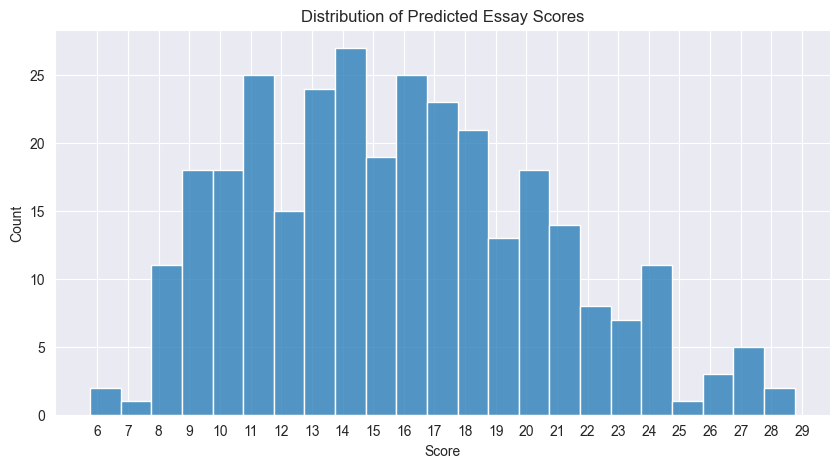

In [347]:
y_pred = ridge_basic.predict(xtest)
minv, maxv = y_pred.min(), y_pred.max()
bins = np.arange(minv, maxv) - 0.5
plt.figure(figsize=(10, 5))
sns.histplot(y_pred, bins=bins, kde=False)
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Distribution of Predicted Essay Scores')
plt.xticks(np.arange(int(minv), int(maxv) + 1, 1))
plt.show()

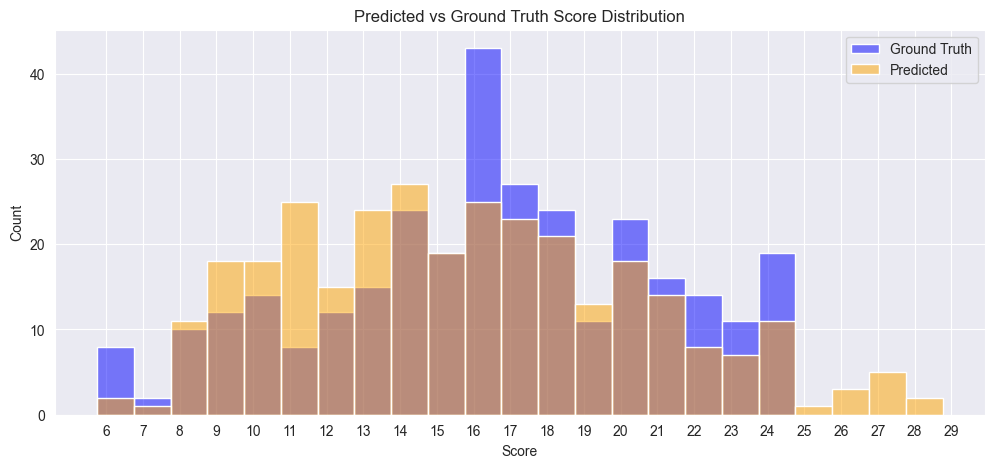

In [348]:
bins = np.arange(minv, maxv) - 0.5
plt.figure(figsize=(12, 5))
sns.histplot(ytest, bins=bins, color='blue', label='Ground Truth', alpha=0.5)
sns.histplot(y_pred, bins=bins, color='orange', label='Predicted', alpha=0.5)
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Predicted vs Ground Truth Score Distribution')
plt.legend()
plt.xticks(np.arange(int(minv), int(maxv) + 1, 1))
plt.show()

The predicted scores are way off. They go all the way up to 36, while the ground truth scores only go up to 22. The predicted scores are skewed more heavily to lower scores, while the ground truth scores are more concentrated around the higher scores.

### Q8: Train a new model using TF-IDF instead of term frequencies
🎒<font color='red'>(1 points)</font>

Repeat the last two steps but use the `TfidfVectorizer` class instead of the `CountVectorizer` class.  TF-IDF stands for Term Frequency Inverse Document Frequency: this class creates a vector with one position for each word in the corpus with a value of the number of occurrences of that word in the essay (term frequency) divided by (i.e., normalized by) the number of documents in which that term appears (inverse document frequency).  (Why do we normalize by document frequency?)

You can pass in a set of stopwords to prevent those words from being used as part of the corpus.   The library nltk includes a set of stopwords.

Report the score of a Ridge model trained using these vectors.  Does the performance improve?  Why?

In [349]:
tv = TfidfVectorizer()
tv.fit(train['essay'])
xtrain = tv.transform(train['essay'])
ytrain = train['score']
xtest = tv.transform(test['essay'])
ytest = test['score']
print(xtrain.shape)
print(xtest.shape)

ridge_tfid = Ridge()
ridge_tfid.fit(xtrain, ytrain)
cs = ridge_tfid.score(xtest, ytest)
print(f"Coefficient of determination R2: {cs:.3f}")
y_pred_best_conventional_ridge_tfid = ridge_tfid.predict(xtest)

(1255, 9038)
(314, 9038)
Coefficient of determination R2: 0.569


<b>Why do we normalize by document frequency?</b><p>
By Normalizing by document frequency, we reduce the impact of common words that appear in many documents, which may not be as informative for distinguishing between different essays. This helps to highlight more unique and relevant terms that contribute to the meaning of the text, leading to better performance in tasks like essay scoring.

<b>Does the performance improve with Term Frequency Inverse Document Frequency?</b><p>
Absolutely, the model performs much better with Term Frequency Inverse Document Frequency (TF-IDF) compared to just using term frequencies. The coefficient of determination (R2) is significantly higher 52%, indicating that the model can explain more of the variance in the essay scores. This is likely because TF-IDF takes into account the importance of terms relative to their frequency across documents, which helps to better capture the nuances of the text.

### Q9: Plot the distribution of scores
🎒<font color='red'>(1 point)</font>

Plot a histogram of your predicted scores from your new model.

Plot another histogram of the ground truth scores.

How is your new model's distribution of scores different from the ground truth distribution? Is it doing better than your first model?  How is it doing better?

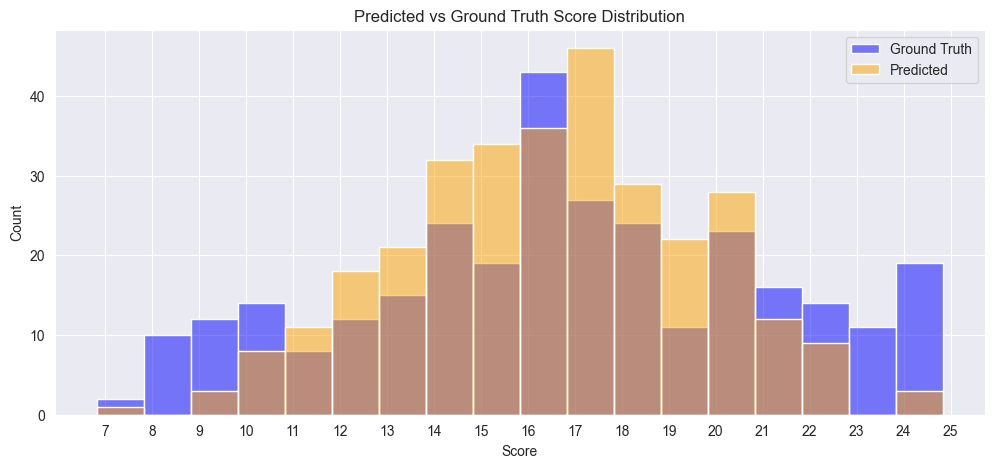

In [350]:
y_pred = ridge_tfid.predict(xtest)
minv, maxv = y_pred.min(), y_pred.max()
bins = np.arange(minv, maxv) - 0.5
plt.figure(figsize=(12, 5))
sns.histplot(ytest, bins=bins, color='blue', label='Ground Truth', alpha=0.5)
sns.histplot(y_pred, bins=bins, color='orange', label='Predicted', alpha=0.5)
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Predicted vs Ground Truth Score Distribution')
plt.legend()
plt.xticks(np.arange(int(minv), int(maxv) + 1, 1))
plt.show()

This model absolutely performs better than the first model. The predicted scores are much closer to the ground truth scores, and the distribution of predicted scores is more aligned with the distribution of ground truth scores. The predicted scores are now mostly within the range of 2 to 22, which is the range of the ground truth scores. The model is still slightly skewed towards lower scores, but it is a significant improvement over the previous model.

### Q10: Try to improve on your model
🎒<font color='red'>(5 points)</font>

Try to find a model that produces a better score.  Some ideas to consider:

* Use the `ngram_range` parameter of the vectorizer to consider bi-grams (two-term combinations) or tri-grams (three term combinations)
* Use the `stopwords` parameter to customize the set of words to ignore when using the corpus.  The library nltk includes a set of stopwords in the corpus module. 
* Use the `alpha` parameter of the Ridge model to change the strength of regularization.
* Use a different linear model, e.g., [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html#sklearn.linear_model.Lasso)

Report the score (and make sure the score is still $R^2$ so it can be compared with your previous score.

Once again, include a plot of the histogram of scores to get a sense of what kind of mistakes your model is making.

In [351]:
# Download stopwords
nltk.download('stopwords')
stop_words = stopwords.words('english')

# Use bi-grams and remove stopwords
vectorizer = TfidfVectorizer(ngram_range=(1,2), stop_words=stop_words)
vectorizer.fit(train['essay'])
xtrain = vectorizer.transform(train['essay'])
xtest = vectorizer.transform(test['essay'])
ytrain = train['score']
ytest = test['score']

# Ridge regression with tuned alpha
ridge_tuned = Ridge(alpha=.1)
ridge_tuned.fit(xtrain, ytrain)
ridge_tuned_r2 = ridge_tuned.score(xtest, ytest)
print(f"Ridge R2: {ridge_tuned_r2:.3f}")

# Lasso regression
lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(xtrain, ytrain)
lasso_r2 = lasso.score(xtest, ytest)
print(f"Lasso R2: {lasso_r2:.3f}")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/stevegon/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Ridge R2: 0.455
Lasso R2: 0.229


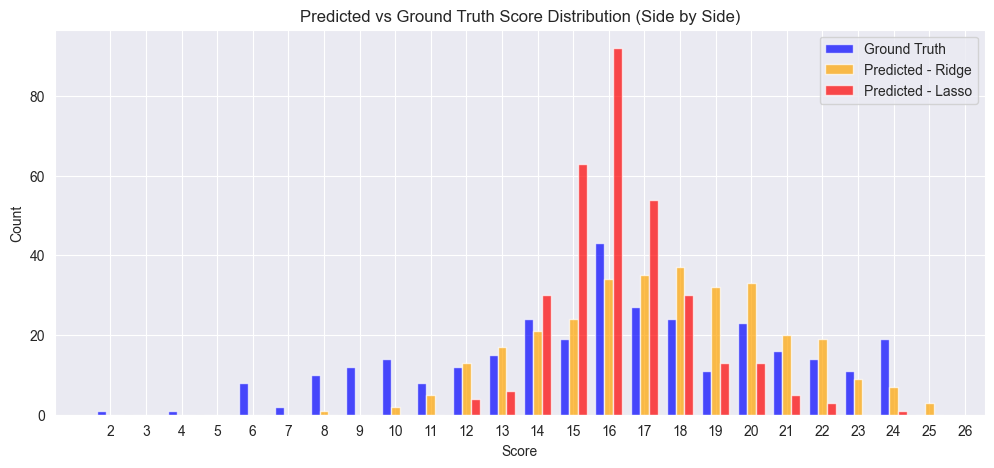

In [352]:
y_pred_ridge = ridge_tuned.predict(xtest)
y_pred_lasso = lasso.predict(xtest)
minv, maxv = int(min(ytest.min(), y_pred_ridge.min(), y_pred_lasso.min())), int(max(ytest.max(), y_pred_ridge.max(), y_pred_lasso.max())) + 1
bins = np.arange(minv, maxv) - 0.5

# Calculate histogram counts for each group
counts_test, _ = np.histogram(ytest, bins=bins)
counts_ridge, _ = np.histogram(y_pred_ridge, bins=bins)
counts_lasso, _ = np.histogram(y_pred_lasso, bins=bins)

x = bins[:-1] + 0.5  # Center of each bin
width = 0.25

plt.figure(figsize=(12, 5))
plt.bar(x - width, counts_test, width=width, color='blue', label='Ground Truth', alpha=0.7)
plt.bar(x, counts_ridge, width=width, color='orange', label='Predicted - Ridge', alpha=0.7)
plt.bar(x + width, counts_lasso, width=width, color='red', label='Predicted - Lasso', alpha=0.7)
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Predicted vs Ground Truth Score Distribution (Side by Side)')
plt.legend()
plt.xticks(np.arange(minv, maxv, 1))
plt.show()

Neither Ridge (modified) nor Lasso models improved the R2 score compared to the previous TF-IDF model. The Ridge model achieved an R2 of 0.443, while the Lasso model achieved an R2 of 0.232.<p>
The Modified Ridge model with bi-grams and stopwords came pretty close in the high frequency bins, but could not predict low scores and predicted too many high scores (continuing this pattern from previous models).

## Part 3: Neural Network Representations


For this part, we will implement a deep sentence embedder to replace the feature selection process. As a first step, choose your best-performing model from Part 2.

This time, you will obtain vectors by using a pre-trained neural network model called the Universal Sentence Encoder.  This model will produce a dense vector from any sequence of text.  (What do I mean by dense?)

First, import the model with the following code.  This step will take considerable time -- it is downloading a large pre-trained model for the first time.

In [353]:
use_module_url = "https://tfhub.dev/google/universal-sentence-encoder/4"
use_model = hub.load(use_module_url)

This model created a dense vector for each string of text. A dense vector is a vector where most of the values are non-zero, as opposed to a sparse vector where most of the values are zero.

### Q11: Generate embeddings
🎒<font color='red'>(1 point)</font>

Next, you will embed the data with the imported model. The Universal Sentence Encoder takes a list of strings and generates an embedding (i.e., a vector) for each string. 

You can call the model you downloaded like a function. 

Generate a vector for each string in the training set; call this array xtrain.

Also generate a vector for each string in the test set; call this array xtest.

Notice how long this step takes -- it's a big model.

In [354]:
# Generate embeddings for training and test sets
xtrain = use_model(list(train['essay'])).numpy()
xtest = use_model(list(test['essay'])).numpy()
print(xtrain[:5])
print(xtest[:5])

[[-0.04364606 -0.08356089  0.02737059 ... -0.02840618 -0.04363095
  -0.05420643]
 [-0.01606898 -0.02564099  0.02272154 ... -0.04737284  0.03704898
  -0.01719167]
 [-0.05026607 -0.08591028 -0.00040817 ...  0.00407815 -0.02308278
  -0.02476197]
 [-0.08147154 -0.05576085  0.04638778 ... -0.01724607 -0.0374588
  -0.06715822]
 [-0.0612321  -0.05059889  0.01351712 ...  0.03441636  0.00309569
  -0.06398933]]
[[-4.5744125e-02 -4.2185437e-02  1.8436801e-02 ...  5.6037284e-02
   9.4990944e-03 -4.1584615e-02]
 [-5.5107545e-02 -4.1394938e-02 -2.6199499e-02 ...  4.2040847e-02
  -3.0636206e-02 -2.5069302e-02]
 [-4.9308576e-02 -6.5329172e-02  4.2615995e-02 ...  2.7648296e-02
   3.6939334e-02 -3.0229254e-02]
 [-5.9915449e-02 -5.9487972e-02  2.5985321e-02 ...  3.4622047e-02
   2.3415960e-05 -2.4807766e-02]
 [-2.0525325e-02 -9.6971393e-02 -4.7078848e-02 ... -1.5068607e-02
   1.0407857e-02 -2.3743052e-03]]


### Q12: Train and evaluate a regression model to predict scores using learned embeddings
🎒<font color='red'>(1 point)</font>

Now retrain your regression model on these learned embeddings instead of the tfidf vectors.

Use the vanilla Ridge model.  Report the score. 

Which model appears to perform the best?

In [355]:
ytrain = train['score'].values
ytest = test['score'].values

ridge_use = Ridge(alpha=1.0)
ridge_use.fit(xtrain, ytrain)
cs = ridge_use.score(xtest, ytest)
print(f"Coefficient of determination R2: {cs:.3f}")

Coefficient of determination R2: 0.672


This model is the best model so far, with an R2 score of 0.672. This indicates that the model can explain in excess of 87% of the variance in the essay scores based on the learned embeddings from the Universal Sentence Encoder. The embeddings capture semantic meaning and context better than the previous term frequency or TF-IDF models, leading to improved performance.

### Q13: Plot the distribution of scores
🎒<font color='red'>(1 point)</font>


Once again, plot a histogram of your predicted scores from your new model.

Plot another histogram of the ground truth scores.

How is your new model's distribution of scores different from the ground truth distribution? Is it doing better than your earlier models?  How is it doing better?


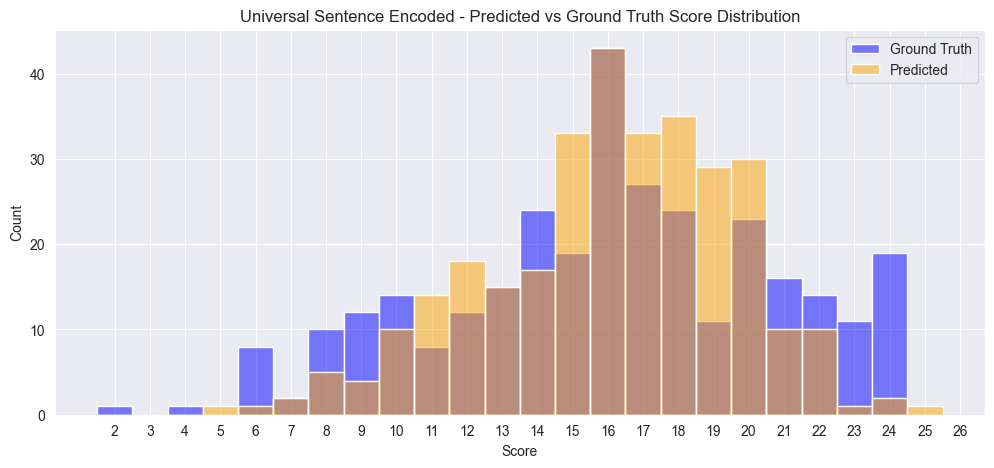

In [356]:
y_pred = ridge_use.predict(xtest)
minv, maxv = min(ytest.min(), y_pred.min()), max(ytest.max(), y_pred.max()) + 1
bins = np.arange(minv, maxv) - 0.5
plt.figure(figsize=(12, 5))
sns.histplot(ytest, bins=bins, color='blue', label='Ground Truth', alpha=0.5)
sns.histplot(y_pred, bins=bins, color='orange', label='Predicted', alpha=0.5)
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Universal Sentence Encoded - Predicted vs Ground Truth Score Distribution')
plt.legend()
plt.xticks(np.arange(int(minv), int(maxv) + 1, 1))
plt.show()

### Q14: Plot the errors
🎒<font color='red'>(1 point)</font>

We will analyze the difference between the neural model and your best conventional model.

Plot the distribution of errors -- see where the two models made mistakes.

The errors are your model's predicted score minus the ground truth human score.

Plot a boxplot of the errors for your model using the universal sentence encoder.  Use the seaborn histplot function. 

x will be the ground truth scores and y is the difference between ground truth and your predictions.  

What do you see?  Where does the model tend to make mistakes?

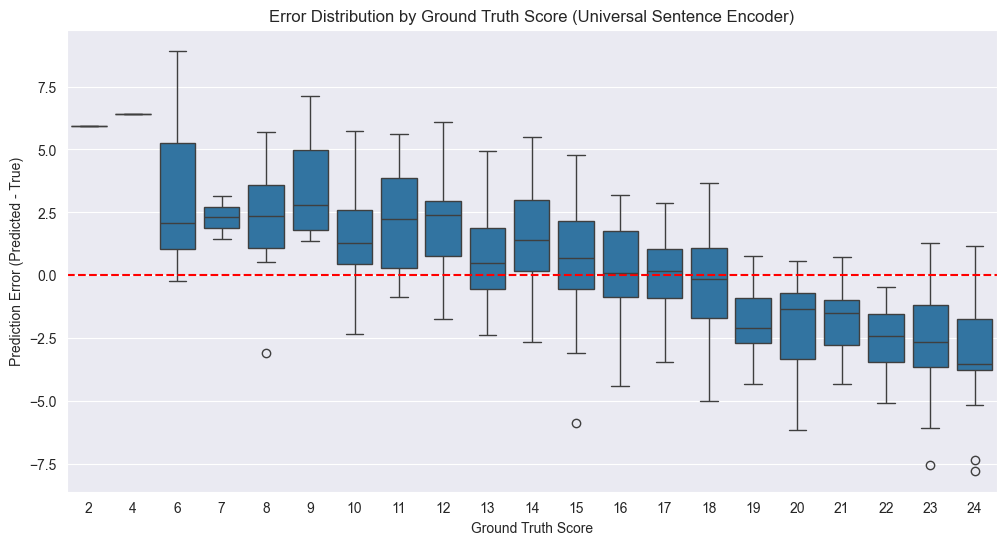

In [357]:
# Calculate errors (Prediction - Truth)
errors_use = y_pred - ytest

# Create a DataFrame for plotting
df_errors_use = pd.DataFrame({'Score': ytest, 'Error': errors})

plt.figure(figsize=(12, 6))
sns.boxplot(x='Score', y='Error', data=df_errors_use)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Ground Truth Score')
plt.ylabel('Prediction Error (Predicted - True)')
plt.title('Error Distribution by Ground Truth Score (Universal Sentence Encoder)')
plt.show()

The BoxPlot tells us that many of the errors are between 2 and 4 points, with a few outliers that are much larger. The model tends to overestimate the scores, as indicated by the positive errors. The median error is slightly positive, suggesting that the model generally predicts higher scores than the ground truth. There are also some negative errors, indicating underestimation, but they are less frequent and less extreme than the overestimations.

Reference to the above BoxPlot:
 - Top horizontal line (upper whisker): The largest data point within 1.5 × IQR above the 75th percentile (Q3).
 - Bottom horizontal line (lower whisker): The smallest data point within 1.5 × IQR below the 25th percentile (Q1).
 - Rectangle (box): Spans from the 25th percentile (Q1, bottom of box) to the 75th percentile (Q3, top of box); this is the interquartile range (IQR).
 - Line inside rectangle: The median (50th percentile) of the data.
 - Small circles: Outliers, which are data points that fall outside the whiskers.

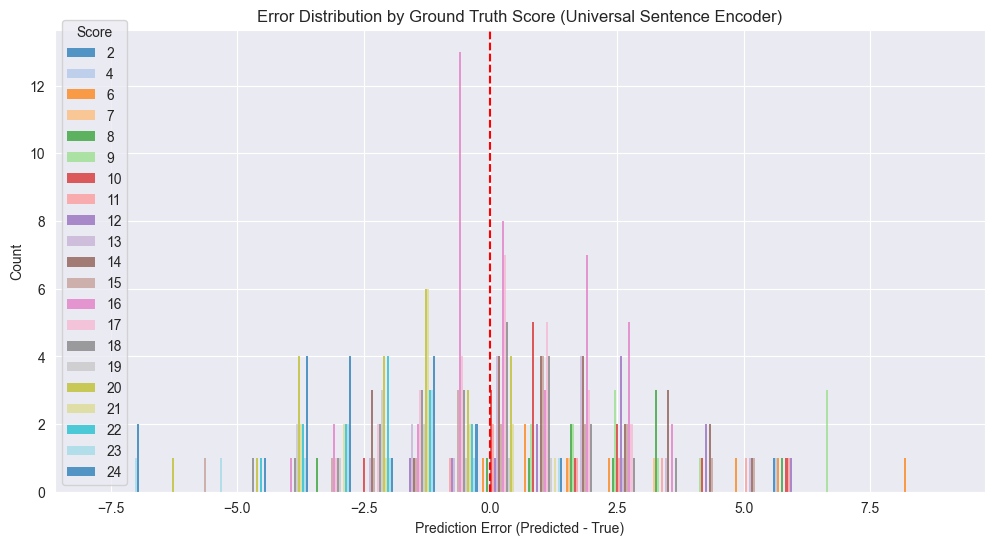

In [358]:
#Histplot; although this is different than in the homework template which shows a boxplot/candlestick plot
plt.figure(figsize=(12, 6))
sns.histplot(data=df_errors_use, x='Error', hue='Score', multiple='dodge', bins=20, palette='tab20', edgecolor='none')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Prediction Error (Predicted - True)')
plt.ylabel('Count')
plt.title('Error Distribution by Ground Truth Score (Universal Sentence Encoder)')
plt.show()

### Q15: Compare models directly
🎒<font color='red'>(1 point)</font>

Plot a histogram of the difference between your neural model and the ground truth.

Plot another histogram of the difference between your best conventional model and the ground truth.


Does either model tend to overestimate or underestimate the true score?

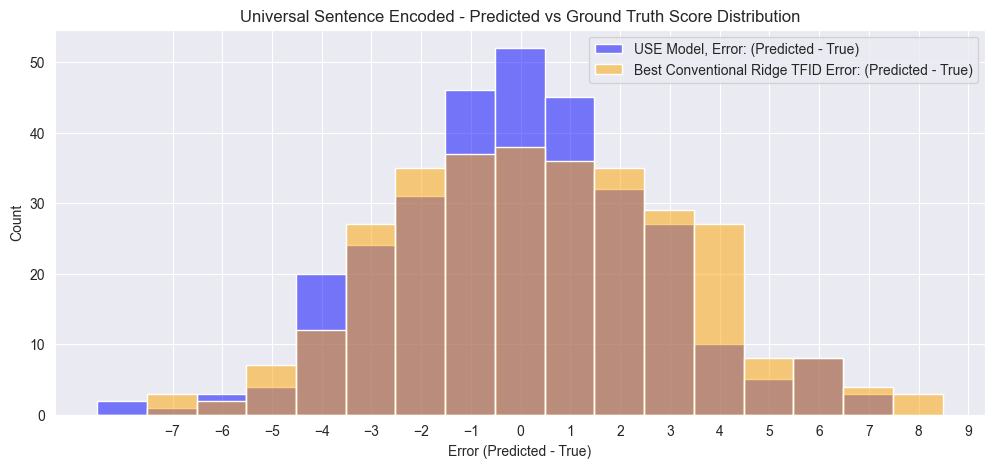

In [363]:
errors_best_conventional_ridge_tfid = y_pred_best_conventional_ridge_tfid - ytest
df_errors_best_conventional = pd.DataFrame({'Score': ytest, 'Error': errors_best_conventional_ridge_tfid})

minv, maxv = df_errors_use["Error"].min(), df_errors_use["Error"].max() + 1
bins = np.arange(minv, maxv) - .75
plt.figure(figsize=(12, 5))
sns.histplot(df_errors_use["Error"], bins=bins, color='blue', label='USE Model, Error: (Predicted - True)', alpha=0.5)
sns.histplot(df_errors_best_conventional["Error"], bins=bins, color='orange', label='Best Conventional Ridge TFID Error: (Predicted - True)', alpha=0.5)
plt.xlabel('Error (Predicted - True)')
plt.ylabel('Count')
plt.title('Universal Sentence Encoded - Predicted vs Ground Truth Score Distribution')
plt.legend()
plt.xticks(np.arange(int(minv), int(maxv) + 1, 1))
plt.show()

The Universal Sentence Encoder model tends to underestimate the true scores more, as indicated by a few more negative errors than the Ridge TF-IDF model.<p>
The Ridge TF-IDF model tends to overestimate the true scores more, as indicated by a few more positive errors than the Universal Sentence Encoder model.<p>

### Q14: Summarize your findings
🎒<font color='red'>(5 points)</font>

Summarize your results. Which approach worked best?  Why?  Does automatic essay scoring appear feasible?  What are some risks or ethical issues with automating this process?   How might we improve on this model?
